# Maximally localized fiber modes

This tutorial demonstrates how to compute the Maximally Localized Fiber Modes (MLFM)
of a multimode fiber using FluxOptics.jl. The idea is to find the unitary transformation
of a given orthonormal mode set that minimizes the total spatial spread of the resulting
modes. Both `unitary_transform` and `spatial_variance` are differentiable in FluxOptics,
so the whole optimization can be driven by automatic differentiation without any manual
gradient derivation.

This tutorial illustrates the method on a single case of N = 28 modes. A systematic
study for N ranging from 6 to 55 modes, along with the theoretical analysis of the
resulting ring geometries, is presented in:

N. Barré, "[Maximally localized modes of a multimode fiber](https://doi.org/10.48550/arXiv.2604.04903),"
arXiv:2604.04903 (2026).

In [1]:
using FluxOptics, Zygote, CairoMakie
using CUDA  # comment if you don't have CUDA
using Random
Random.seed!(6);  # Determinist example

## Input basis: Laguerre-Gaussian modes

We generate a basis of N Laguerre-Gaussian modes for a graded-index fiber.
The modes are grouped by order and sorted by azimuthal index. We choose N = 28,
which corresponds to complete LG mode groups up to order 6.

In [2]:
function generate_lg_basis(ns, ds, λ, w0, n_modes::Int)
    x, y = spatial_vectors(ns, ds)
    n_order = round(Int, sqrt(2 * n_modes)) - 1
    orders = [(p, l) for p in 0:(n_order ÷ 2) for l in (2 * p - n_order):(n_order - 2 * p)]
    sort!(orders, by = ((p, l),) -> (abs(l), p))
    modes = stack(order -> LaguerreGaussian(w0, order...)(x, y), orders; dims = 3)
    ScalarField(modes, ds, λ)
end

ns = (200, 200)
ds = (1.0, 1.0)
λ = 1.55
w0 = 25.0
n_modes = 28

u0 = generate_lg_basis(ns, ds, λ, w0, n_modes)
u0 = cu(u0)  # comment if you don't have CUDA
normalize_power!(u0);

Let's visualize a few representative LG modes (intensity and phase):

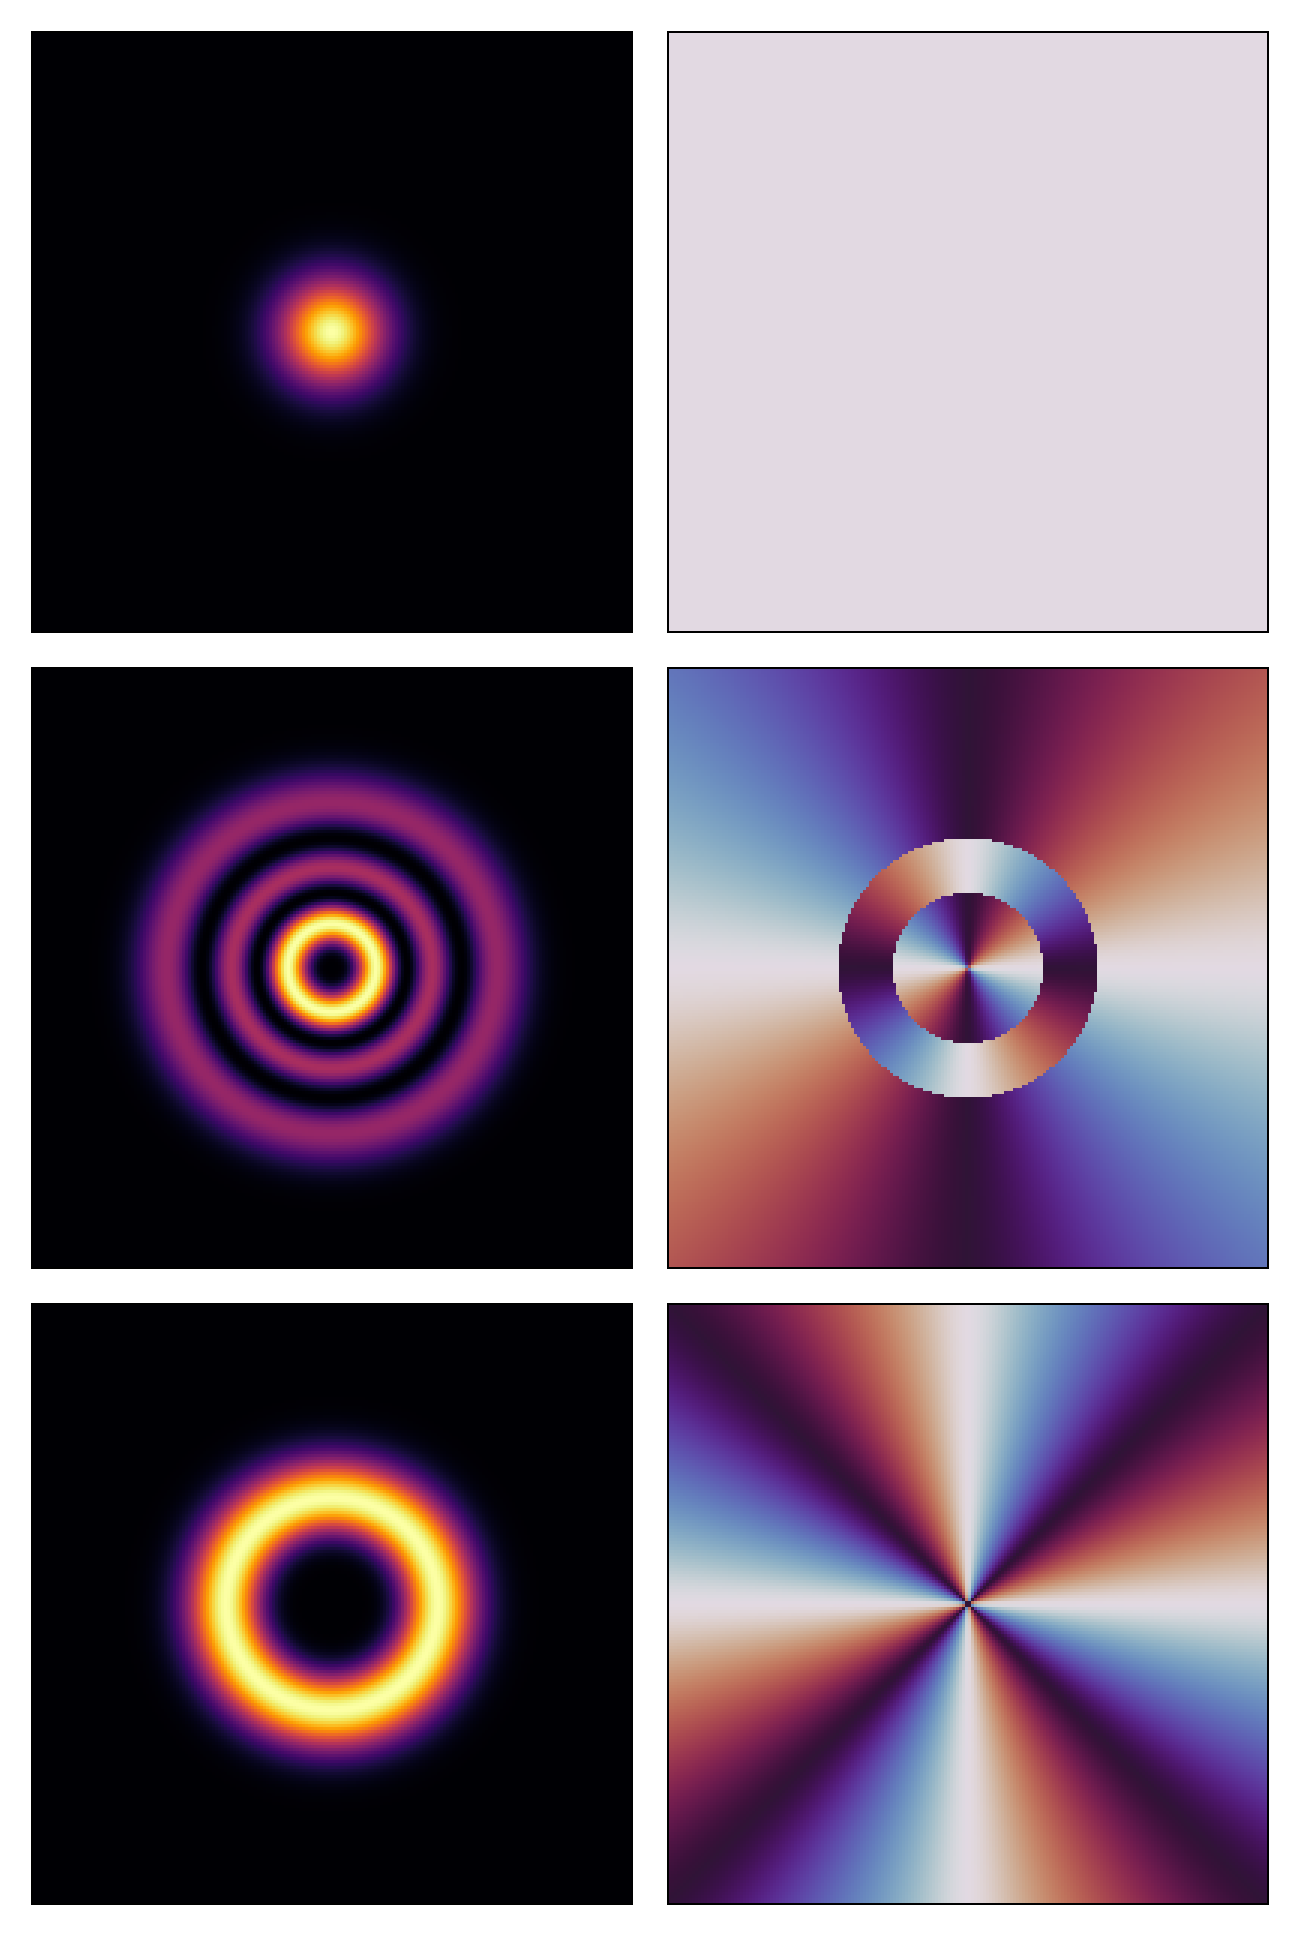

In [3]:
visualize(vec(u0)[[1, 15, 21]], (intensity, phase);
          colormap = (:inferno, :twilight_shifted), height = 300)

## Optimization: finding the maximally localized basis

We parameterize the unitary transformation as U = exp((A - A†)/2), where A is an
unconstrained complex matrix. This guarantees that U remains unitary throughout
the optimization. The loss function is the total spread Ω = Σᵢ 2(vxᵢ + vyᵢ),
where vx and vy are the spatial variances of each mode along x and y.

In [4]:
function find_mlm(u, rule, n_iter::Integer)
    n_modes = size(u, 3)
    A = similar(u.electric, (n_modes, n_modes))
    copyto!(A, rand(ComplexF64, n_modes, n_modes))
    function loss(A)
        vx, vy = spatial_variance(unitary_transform(u, A))
        2*(sum(vx) + sum(vy))
    end
    opt = FluxOptics.setup(rule, A)
    for i in 1:n_iter
        grads = Zygote.gradient(loss, A)
        FluxOptics.update!(opt, A, grads[1])
    end
    unitary_transform(u, A)
end

find_mlm (generic function with 1 method)

We use FISTA with a small step size. A warm-up call compiles the gradient computation.

In [5]:
rule = Fista(0.008)
find_mlm(u0, rule, 2)  # Warm-up
@time uf = find_mlm(u0, rule, 2000);

  6.969834 seconds (8.81 M allocations: 867.972 MiB, 19.99% gc time)


Let's visualize a few modes of the localized basis:

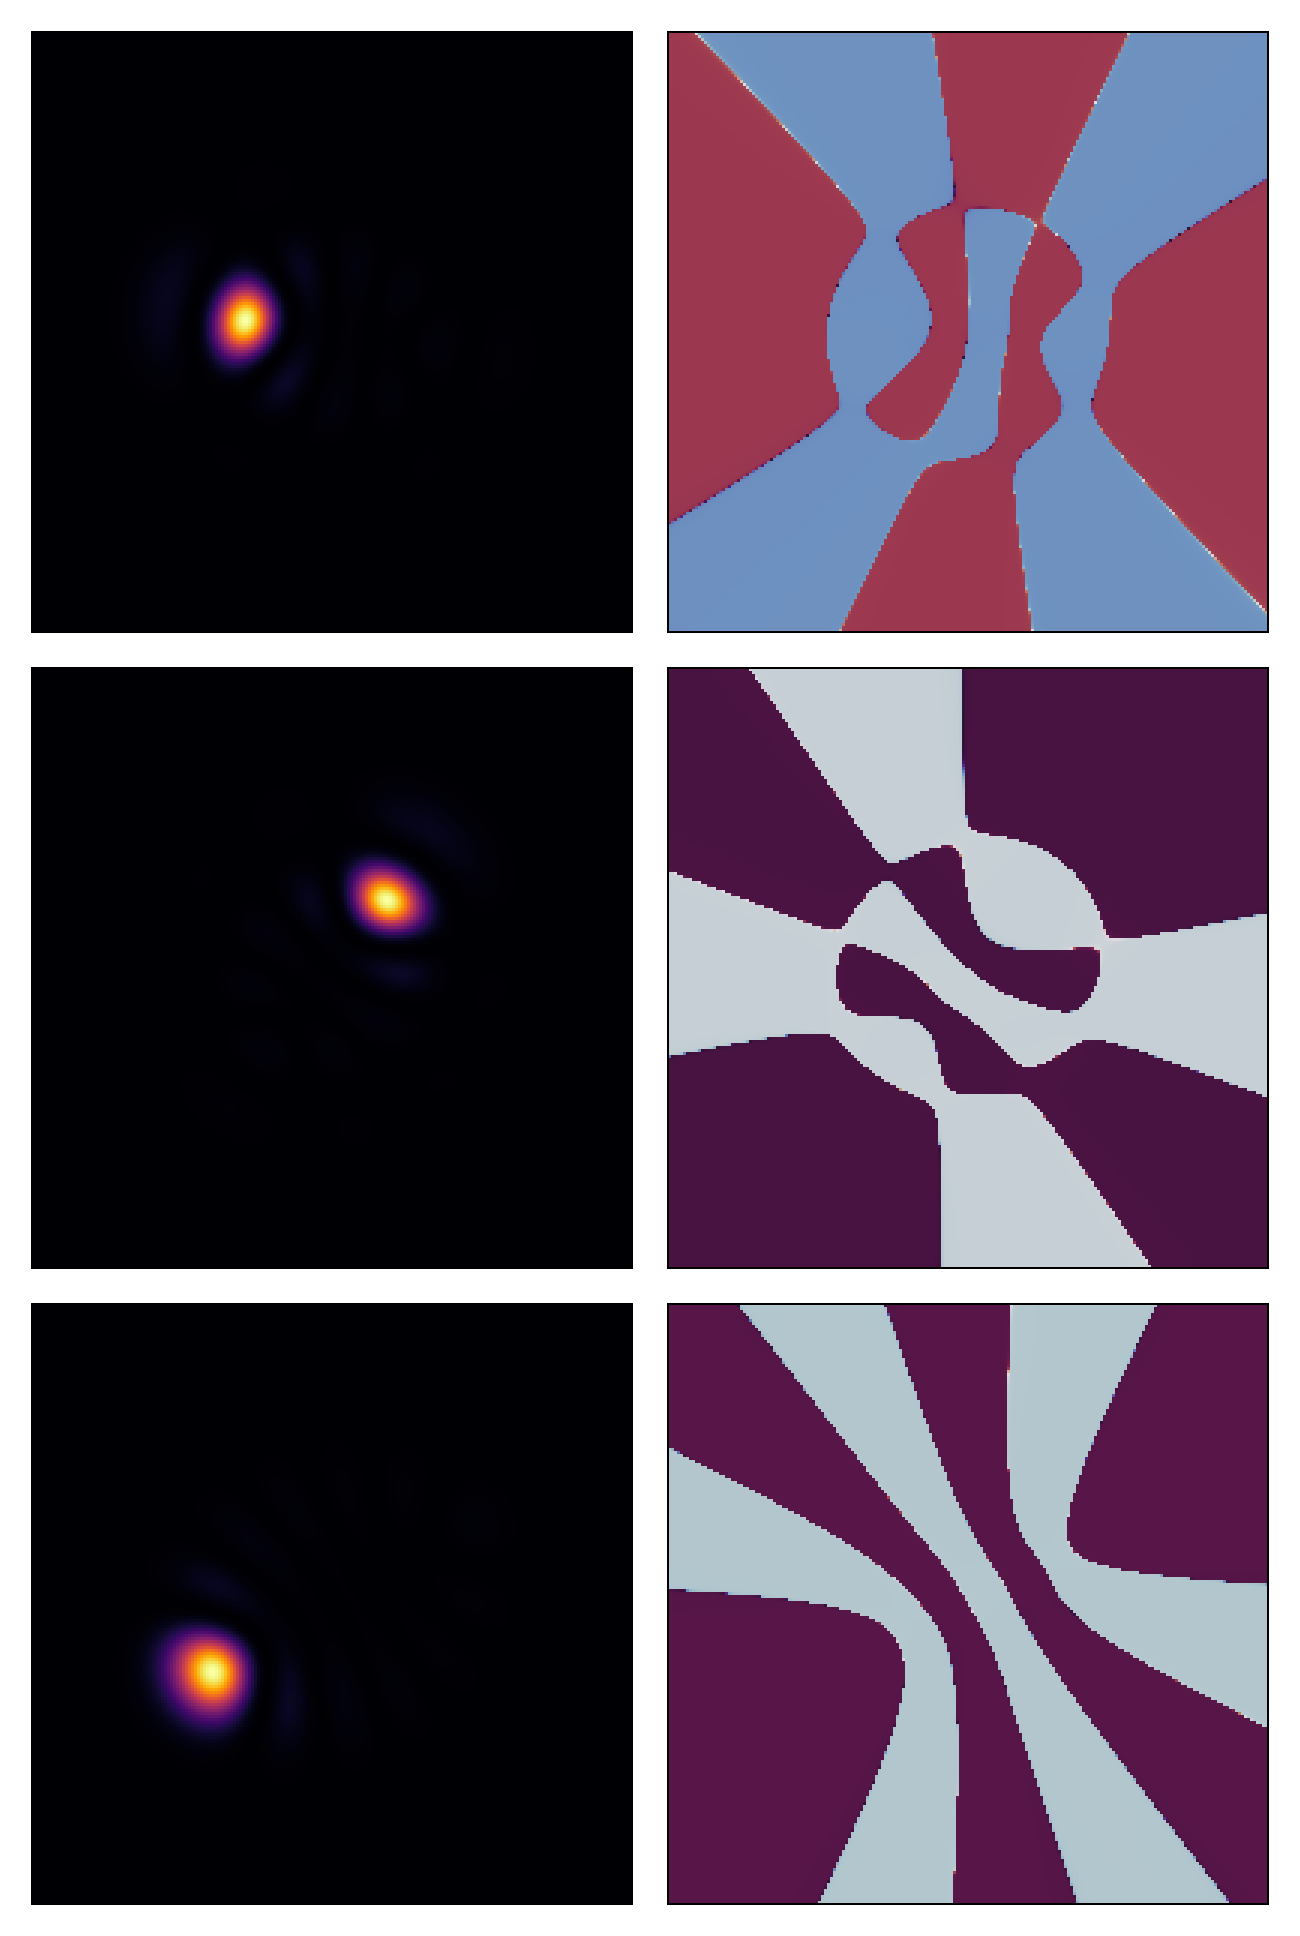

In [6]:
visualize(vec(uf)[[1, 15, 21]], (intensity, phase);
          colormap = (:inferno, :twilight_shifted), height = 300)

The total intensity is invariant under unitary transformation — we verify this:

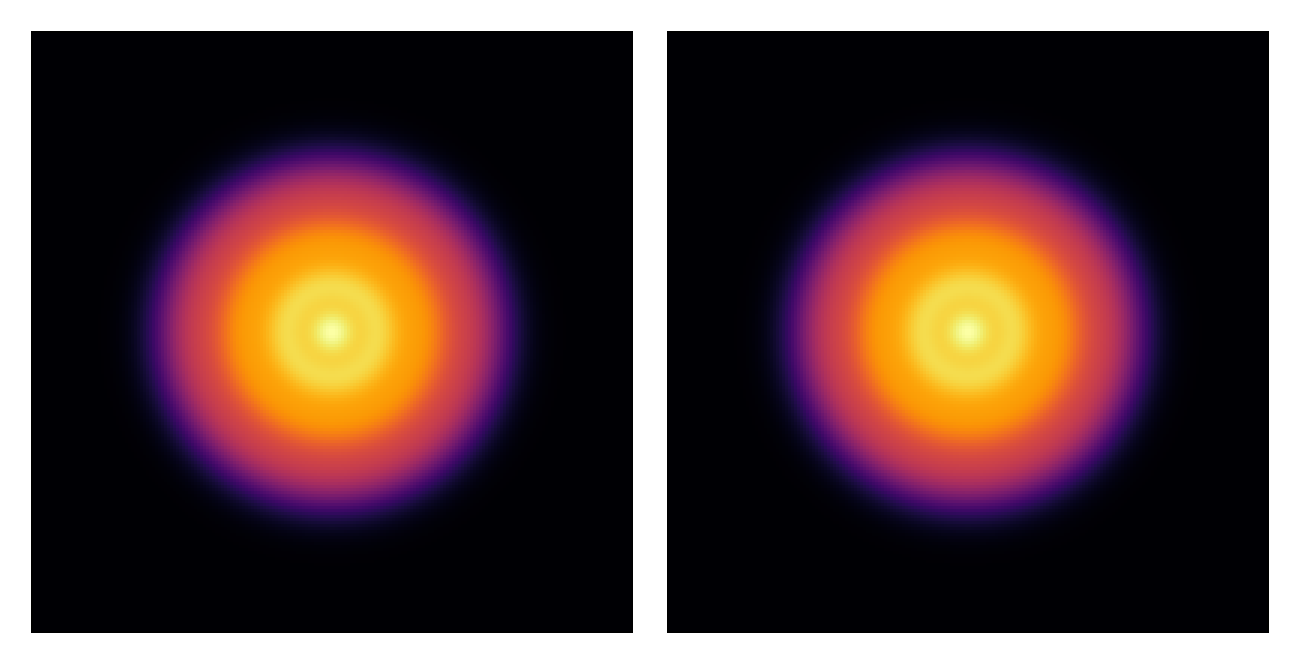

In [7]:
visualize(((u0, uf),), intensity; colormap = :inferno, height = 300)

We can quantify the localization improvement by computing the ratio of total spreads:

In [8]:
spread_ratio = sum(sum(spatial_variance(u0))) / sum(sum(spatial_variance(uf)))

3.5875826f0

## Bundle geometry: spot statistics

We compute the spatial statistics of each mode in the localized basis: centroid
position, radial and azimuthal variances, and orientation angle.
The radial and azimuthal variances are obtained by projecting the principal axes
of the intensity ellipse onto the radial and azimuthal directions.

In [9]:
function spot_statistics(u::ScalarField{U, 2}) where {U}
    cx, cy = spatial_centroids(u)
    cx, cy = collect(cx), collect(cy)
    r = sqrt.(cx .^ 2 .+ cy .^ 2)
    θ = atan.(cy, cx)

    v1, v2, α = spatial_variance(u; principal = true)
    v1, v2, α = collect(v1), collect(v2), collect(α)

    # Project principal axes onto radial direction to assign σ²_r and σ²_θ
    er_x = cx ./ max.(r, 1e-10)
    er_y = cy ./ max.(r, 1e-10)
    e1_x = cos.(α)
    e1_y = sin.(α)
    dot_r = @. abs(e1_x * er_x + e1_y * er_y)

    σ²_r = ifelse.(dot_r .> 0.5, v2, v1)
    σ²_θ = ifelse.(dot_r .> 0.5, v1, v2)

    return (; cx, cy, r, θ, σ²_r, σ²_θ, α)
end

spot_statistics (generic function with 1 method)

## Visualization: bundle geometry with oriented ellipses

Each spot is represented by its centroid and an oriented ellipse whose semi-axes
are proportional to the radial and azimuthal standard deviations.

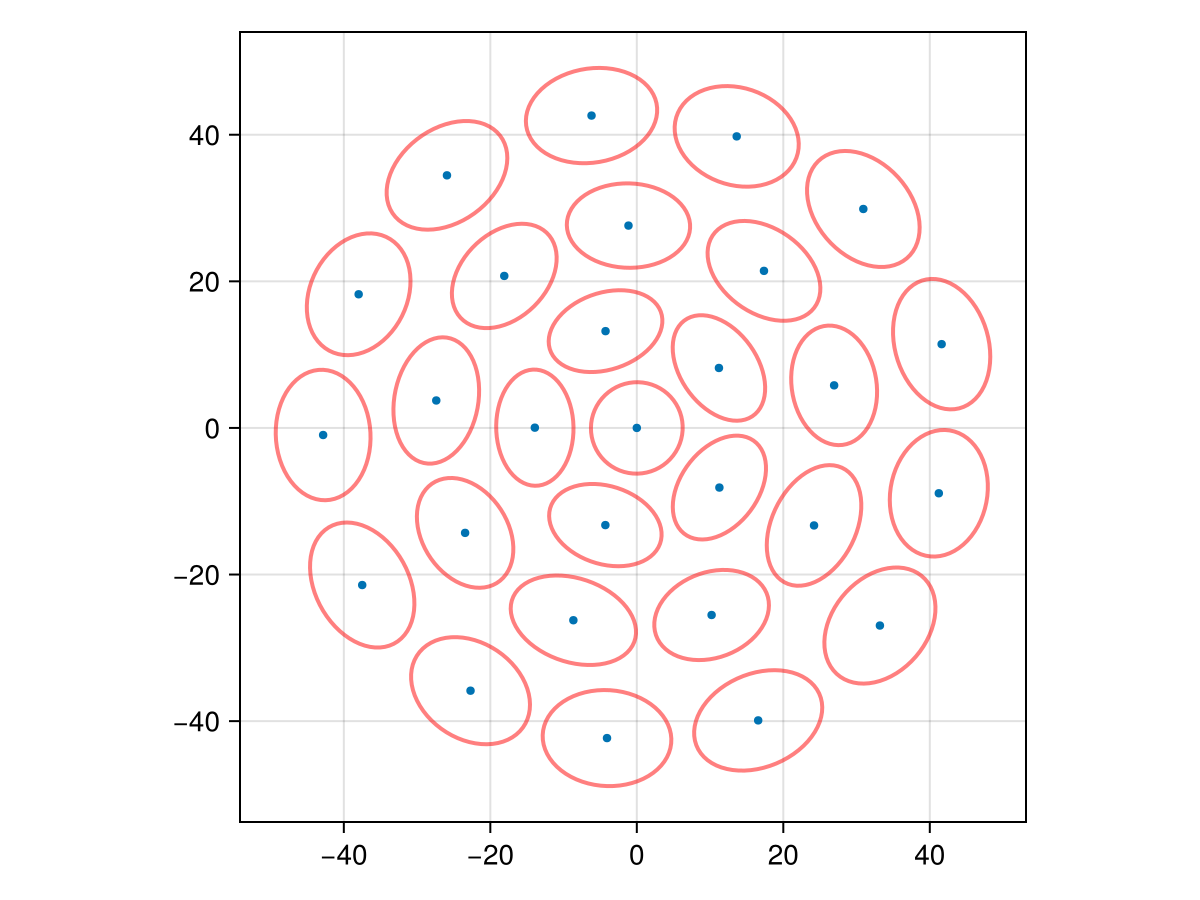

In [10]:
function plot_bundle(stats...;
                     scale = 1.0,
                     show_variance = false,
                     figure = (;))
    fig = Figure(figure...)
    ax = Axis(fig[1, 1]; aspect = DataAspect())
    for s in stats
        scatter!(ax, s.cx, s.cy; markersize = 6)
        if show_variance
            for (x, y, σ²_r, σ²_θ, α) in zip(s.cx, s.cy, s.σ²_r, s.σ²_θ, s.α)
                a = scale * sqrt(σ²_r)
                b = scale * sqrt(σ²_θ)
                t = LinRange(0, 2π, 64)
                ex = @. x + a * cos(t) * cos(α) - b * sin(t) * sin(α)
                ey = @. y + a * cos(t) * sin(α) + b * sin(t) * cos(α)
                lines!(ax, ex, ey; color = (:red, 0.5), linewidth = 2.0)
            end
        end
    end
    fig
end

uf_stats = spot_statistics(uf)

plot_bundle(uf_stats; show_variance = true, scale = 0.5)

The spots spontaneously organize into concentric rings — here [1, 5, 9, 13] for N = 28 —
without any geometric constraint being imposed. The ring structure emerges purely
from the minimization of the spread functional.

## Ring structure from multiple initializations

Since the optimization landscape is non-convex and the problem has a continuous
rotational symmetry (the orientation of the bundle is a free parameter), different
random initializations converge to rotated versions of the same solution.
Running 20 independent optimizations and overlaying all solutions reveals the
underlying concentric ring structure clearly.

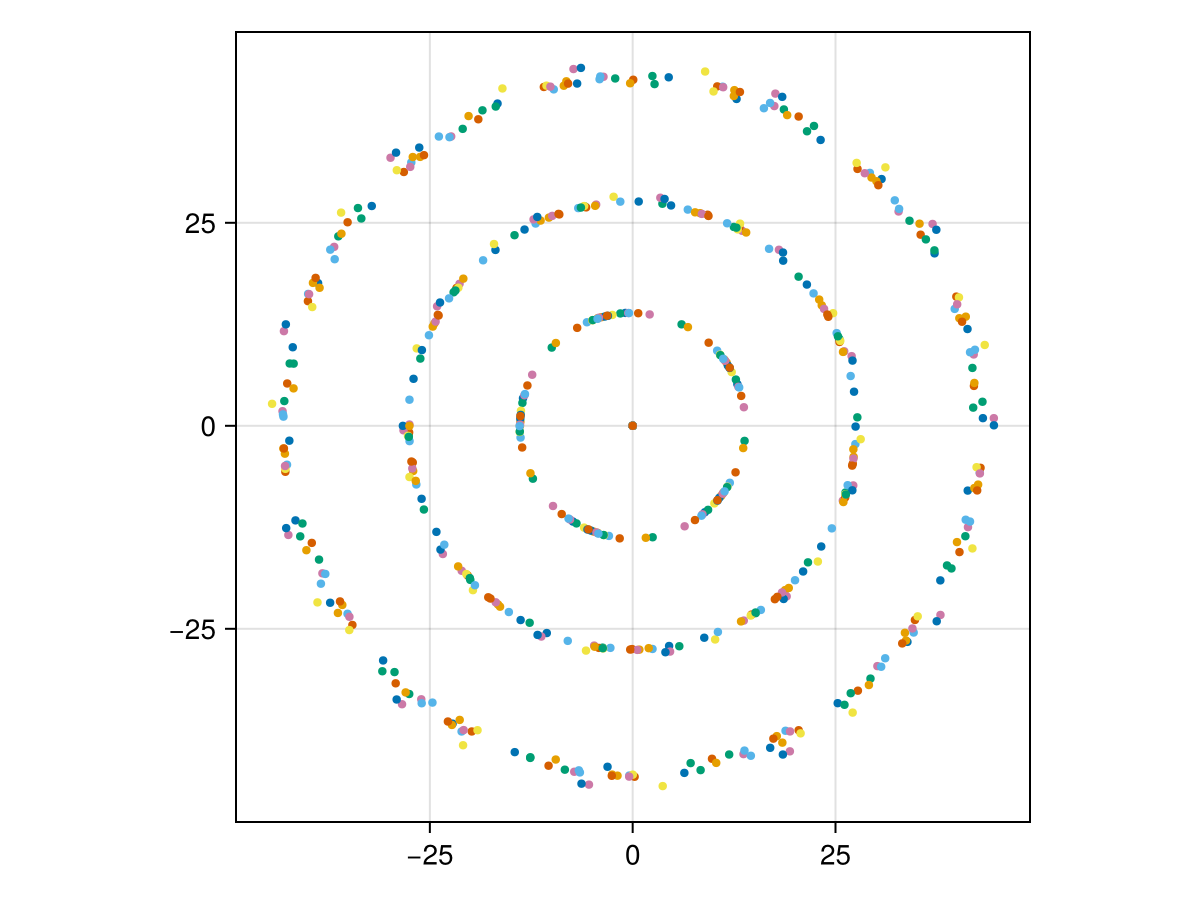

In [11]:
stats = [spot_statistics(find_mlm(u0, rule, 2000)) for _ in 1:20]

plot_bundle(stats...)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*